In [2]:
import subprocess
import os
import pandas as pd
import netCDF4
import numpy as np
import glob
import time
import matplotlib.pyplot as plt
import copy
import xarray as xr
from datetime import datetime, timedelta 
import dask
from scipy.interpolate import griddata
#from ocean_c_lab_tools import *
#from celluloid import Camera 
#import PyCO2SYS as csys
import seawater as sw
from roms_regrid import *

/tmp/ipykernel_1324837/3005166470.py:17: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [2]:
#HAFRO_path='/home/x-uheede/R/HAFRO/Hafro_cruises.xls'
model_grid_path="/home/x-uheede/S/Iceland3_MARBL_2024/P_INPUT/Iceland3_grid.nc"
# Grid parameters, only modify these if grid is made in MATLAB
vert_levels=60
theta_s_model=5
theta_b_model=2
hc_model=300

model_bgc_dia_path1="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR1/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"
model_bgc_dia_path2="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR2/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"
model_bgc_dia_path3="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR3/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"

variables_bgc_dia=['pH_3D','FG_CO2','FG_ALT_CO2','pCO2SURF','pCO2SURF_ALT_CO2']
variables_bgc=['ALK','ALK_ALT_CO2']

model_bgc_path1="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR1/Iceland3_MARBL_2024_bgc.202407????????.nc"
model_bgc_path2="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR2/Iceland3_MARBL_2024_bgc.202407????????.nc"
model_bgc_path3="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR3/Iceland3_MARBL_2024_bgc.202407????????.nc"

model_cstar_path1="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR1/Iceland3_MARBL_2024_cstar.202407????????.nc"
model_cstar_path2="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR2/Iceland3_MARBL_2024_cstar.202407????????.nc"
model_cstar_path3="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR3/Iceland3_MARBL_2024_cstar.202407????????.nc"

target_depth_levels=[1,2,3,4,5,6,7,8,9,10,15] # Specify depth levels of interest
thinner=4 # specify the temporal frequency of data being read (i.e. no need to read in hourly data)


In [3]:
import xarray as xr
import numpy as np
import glob

# =========================
# Ensemble members
# =========================
ensembles = ["CDR1", "CDR2", "CDR3"]

N = vert_levels
theta_s = theta_s_model
theta_b = theta_b_model
hc = hc_model

# =========================
# Load grid (only once)
# =========================
grid = xr.open_dataset(model_grid_path)

h = grid["h"].values
mask_rho = grid["mask_rho"].values.astype(bool)

eta, xi = h.shape

# =========================
# Vertical coordinates
# =========================
k_w = np.linspace(0, N, N + 1)
sigma_w = (k_w - N) / N


def Cs(sigma, theta_s, theta_b):
    C = (1 - np.cosh(theta_s * sigma)) / (np.cosh(theta_s) - 1)
    C = (np.exp(theta_b * C) - 1) / (1 - np.exp(-theta_b))
    return C


Cs_w = Cs(sigma_w, theta_s, theta_b)

sigma_w_3d = sigma_w[:, None, None]
Cs_w_3d = Cs_w[:, None, None]
h_3d = h[None, :, :]

S_w = (hc * sigma_w_3d + h_3d * Cs_w_3d) / (hc + h_3d)

# =========================
# Loop over ensembles
# =========================
for ens in ensembles:

    #print(f"\nProcessing ensemble {ens}")

    his_path = f"/home/x-uheede/S/Iceland3_MARBL_2024_{ens}/Iceland3_MARBL_2024_his.202407*.nc"

    ds = xr.open_mfdataset(
        his_path,
        combine='nested',
        concat_dim=["time"]
    )

    zeta = ds["zeta"]

    thickness_list = []

    for t in range(len(zeta.time)):

        #print(f"{ens} time {t+1}/{len(zeta.time)}")

        zeta_t = zeta.isel(time=t).values

        zeta_3d = zeta_t[None, :, :]

        z_w = zeta_3d + (zeta_3d + h_3d) * S_w

        thickness = np.diff(z_w, axis=0)

        thickness[:, ~mask_rho] = np.nan

        thickness_list.append(thickness)

    thickness_all = np.stack(thickness_list, axis=0)

    # =========================
    # Save as xarray
    # =========================
    thickness_da = xr.DataArray(
        thickness_all,
        dims=["time", "s_rho", "eta_rho", "xi_rho"],
        coords={
            "time": ds.time,
            "s_rho": np.arange(N),
            "eta_rho": ds.eta_rho,
            "xi_rho": ds.xi_rho,
        },
        name="cell_thickness"
    )

    out_file = f"Iceland3_cell_thickness_July2024_{ens}.nc"

    thickness_da.to_netcdf(out_file)

    print(f"Saved {out_file}")

print("\nAll ensembles processed")

KeyboardInterrupt: 

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Paths
# =========================
bgc_paths = {
    "CDR1": "/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR1/Iceland3_MARBL_2024_bgc.202407*.nc",
    "CDR2": "/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR2/Iceland3_MARBL_2024_bgc.202407*.nc",
    "CDR3": "/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR3/Iceland3_MARBL_2024_bgc.202407*.nc",
}

thickness_files = {
    "CDR1": "Iceland3_cell_thickness_July2024_CDR1.nc",
    "CDR2": "Iceland3_cell_thickness_July2024_CDR2.nc",
    "CDR3": "Iceland3_cell_thickness_July2024_CDR3.nc",
}

# =========================
# Grid
# =========================
grid = xr.open_dataset(model_grid_path)

pm = grid["pm"]
pn = grid["pn"]

area = 1 / (pm * pn)  # m2

# =========================
# Storage
# =========================
total_alk_timeseries = {}
surface_alk_fraction = {}

# =========================
# Loop over ensembles
# =========================
for ens in ["CDR1", "CDR2", "CDR3"]:

    print(f"\nProcessing {ens}")

    # ---------------------
    # Load ALK
    # ---------------------
    ds_bgc = xr.open_mfdataset(
        bgc_paths[ens],
        combine="nested",
        concat_dim="time"
    )

    ALK = ds_bgc["ALK"] - ds_bgc["ALK_ALT_CO2"]

    # ---------------------
    # Load thickness
    # ---------------------
    thickness = xr.open_dataset(
        thickness_files[ens]
    )["cell_thickness"]

    # ---------------------
    # Volume
    # ---------------------
    volume = thickness * area

    # =====================
    # Total ALK inventory
    # =====================
    total_alk = (ALK * volume).sum(
        dim=["s_rho", "eta_rho", "xi_rho"],
        skipna=True
    )

    total_alk_timeseries[ens] = total_alk

    # =====================
    # Surface (upper two layers)
    # =====================
    ALK_surface = ALK.isel(s_rho=slice(58, 60))
    volume_surface = volume.isel(s_rho=slice(58, 60))

    surface_alk = (ALK_surface * volume_surface).sum(
        dim=["s_rho", "eta_rho", "xi_rho"],
        skipna=True
    )

    # =====================
    # Fraction of total ALK in surface
    # =====================
    surface_fraction = surface_alk / total_alk

    surface_alk_fraction[ens] = surface_fraction

    print("done")


Processing CDR1
done

Processing CDR2
done

Processing CDR3
done


In [12]:
# =========================
# Convert dictionaries to Dataset
# =========================
ds_out = xr.Dataset()

for ens in ["CDR1", "CDR2", "CDR3"]:

    total_ts = total_alk_timeseries[ens]
    surface_ts = surface_alk_fraction[ens]

    # Apply same time shift used in plotting
    if ens == "CDR1":
        total_ts = total_ts.copy()
        surface_ts = surface_ts.copy()

        #total_ts["time"] = total_ts["time"] + 34
        surface_ts["time"] = surface_ts["time"] + 34

    ds_out[f"total_alk_{ens}"] = total_ts
    ds_out[f"surface_fraction_{ens}"] = surface_ts


# =========================
# Add metadata
# =========================
ds_out["total_alk_CDR1"].attrs["units"] = "mol"
ds_out["total_alk_CDR2"].attrs["units"] = "mol"
ds_out["total_alk_CDR3"].attrs["units"] = "mol"

ds_out["surface_fraction_CDR1"].attrs["units"] = "fraction"
ds_out["surface_fraction_CDR2"].attrs["units"] = "fraction"
ds_out["surface_fraction_CDR3"].attrs["units"] = "fraction"

ds_out.attrs["description"] = "Total alkalinity inventory and surface fraction (s_rho 58-59)"
ds_out.attrs["model"] = "Iceland3 MARBL July 2024"
ds_out.attrs["created_by"] = "ALK inventory calculation script"


# =========================
# Save NetCDF
# =========================
ds_out.to_netcdf(
    "Iceland3_total_alk_and_surface_fraction.nc"
)

print("NetCDF saved: Iceland3_total_alk_and_surface_fraction.nc")

NetCDF saved: Iceland3_total_alk_and_surface_fraction.nc


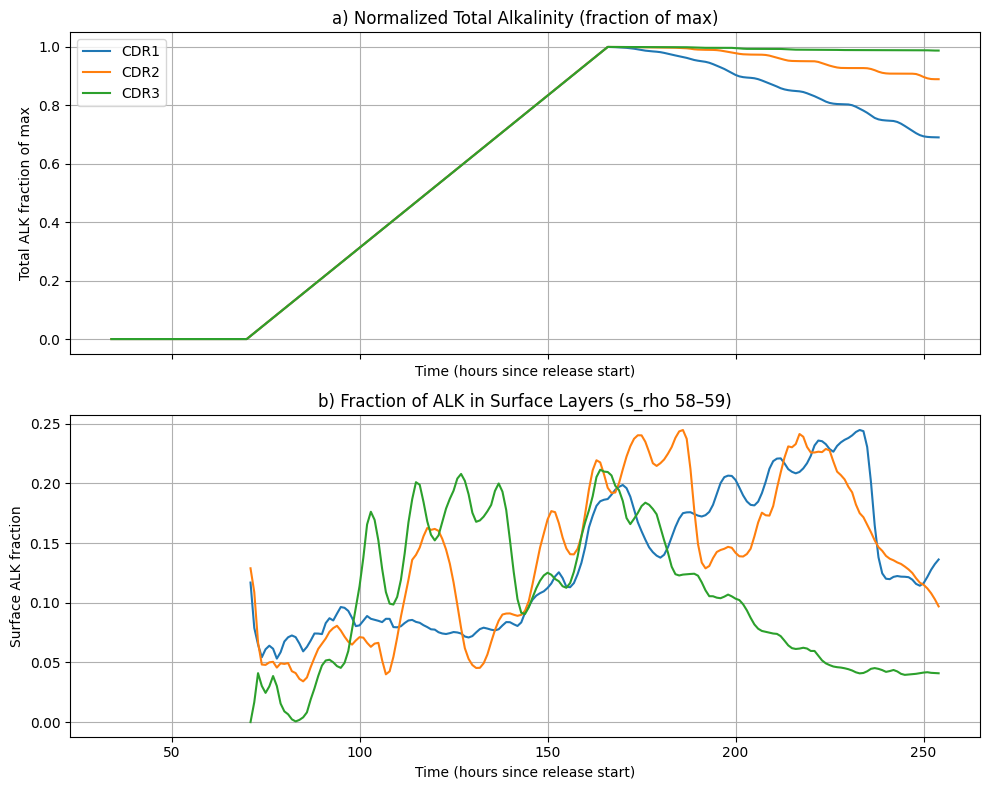

In [5]:
import xarray as xr
import matplotlib.pyplot as plt

import xarray as xr
import matplotlib.pyplot as plt

# -------------------------
# Read NetCDF
# -------------------------
ds = xr.open_dataset("Iceland3_total_alk_and_surface_fraction.nc")

# Identify the total ALK variables
total_alk_vars = [v for v in ds.data_vars if v.startswith("total_alk")]

# Create dictionary keyed by ensemble name
total_alk_timeseries = {v.split("_")[-1]: ds[v] for v in total_alk_vars}

# Identify the total ALK variables
surface_alk_fraction = [v for v in ds.data_vars if v.startswith("surface_fraction")]

# Create dictionary keyed by ensemble name
surface_alk_fraction = {v.split("_")[-1]: ds[v] for v in surface_alk_fraction}

# -------------------------
# Plot normalized total alkalinity
# -------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for ens, ts in total_alk_timeseries.items():
    # Normalize by maximum value of this ensemble
    ts_frac = ts / ts.max()
    ax1.plot(ts["time"], ts_frac.load(), label=ens)

ax1.set_ylabel("Total ALK fraction of max")
ax1.set_xlabel("Time (hours since release start)")
ax1.set_title("a) Normalized Total Alkalinity (fraction of max)")
ax1.grid(True)
ax1.legend()



# b) Surface fraction
for ens, ts in surface_alk_fraction.items():
    ax2.plot(ts["time"], ts.load(), label=ens)

ax2.set_ylabel("Surface ALK fraction")
ax2.set_xlabel("Time (hours since release start)")
ax2.set_title("b) Fraction of ALK in Surface Layers (s_rho 58–59)")
ax2.grid(True)

# Save figure
plt.tight_layout()
plt.savefig("total_alk_and_surface_fraction_timeseries.png", dpi=300)
plt.show()

In [8]:
ts

<xarray.DataArray (time: 221)> Size: 2kB
dask.array<sum-aggregate, shape=(221,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) int64 2kB 34 35 36 37 38 39 40 ... 249 250 251 252 253 254

In [ ]:
from roms_tools import Grid, ROMSOutput

grid = Grid.from_file(
    model_grid_path
)

#Only run this cell if grid is made in MATLAB
grid.update_vertical_coordinate(N=vert_levels, theta_s=theta_s_model, theta_b=theta_b_model, hc=hc_model, verbose=False)


In [ ]:
import xarray as xr
import numpy as np

# -----------------------------------
# Group paths
# -----------------------------------
path_dict = {
    "bgc": [
        model_bgc_path1,
        model_bgc_path2,
        model_bgc_path3,
    ]
}

# -----------------------------------
# Variable lists
# -----------------------------------
var_dict = {
    "bgc": variables_bgc
}

# -----------------------------------
# Loop and create roms_* and ds_* variables
# -----------------------------------
for key, paths in path_dict.items():

    for i, path in enumerate(paths, start=1):

        # Create ROMSOutput object
        roms_obj = ROMSOutput(
            grid=grid,
            path=[path],
            use_dask=True
        )

        # Assign roms_* variable (e.g., roms_bgc1)
        globals()[f"roms_{key}{i}"] = roms_obj

        # Regrid
        if var_dict[key] is not None:
            ds = roms_obj.regrid(
                depth_levels=target_depth_levels,
                var_names=var_dict[key]
            )
        else:
            ds = roms_obj.regrid(
                depth_levels=target_depth_levels
            )

        # Assign ds_* variable (e.g., ds_bgc1)
        globals()[f"ds_{key}{i}"] = ds

In [ ]:
def get_start_time(ds, threshold=1e-6):

    diff = ds["ALK"].isel(depth=0) - ds["ALK_ALT_CO2"].isel(depth=0)

    # boolean signal over domain
    signal = (np.abs(diff) > threshold).any(dim=("lat", "lon"))

    # compute only the 1D signal
    signal = signal.compute()

    # first time where signal appears
    t0 = ds.time.sel(time=signal).min()

    return t0


def add_relative_time(ds, t0):

    time_rel = (ds.time - t0) / np.timedelta64(1, "h")

    return ds.assign_coords(time_rel=("time", time_rel.data))

# Compute start times
t0_1 = get_start_time(ds_bgc1)
t0_2 = get_start_time(ds_bgc2)
t0_3 = get_start_time(ds_bgc3)

# Add relative time

ds_bgc1 = add_relative_time(ds_bgc1, t0_1)
ds_bgc2 = add_relative_time(ds_bgc2, t0_2)
ds_bgc3 = add_relative_time(ds_bgc3, t0_3)



ds_bgc1 = ds_bgc1.swap_dims({"time": "time_rel"})
ds_bgc2 = ds_bgc2.swap_dims({"time": "time_rel"})
ds_bgc3 = ds_bgc3.swap_dims({"time": "time_rel"})

time_rel_common = np.arange(-48, 240, 1)  # hours

ds_bgc1 = ds_bgc1.interp(time_rel=time_rel_common)
ds_bgc2 = ds_bgc2.interp(time_rel=time_rel_common)
ds_bgc3 = ds_bgc3.interp(time_rel=time_rel_common)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Transect coordinates
# =========================
lat0 = 64 + 23/60 + 9.25/3600
lon_w = 360 - (21 + 32/60 + 31.66/3600)
lon_e = 360 - (21 + 26/60 + 5.19/3600)

# =========================
# Plot function
# =========================
def plot_alk_transect(ds, title):

    # ---------------------------------
    # ALK difference
    # ---------------------------------
    alk_diff = ds["ALK"] - ds["ALK_ALT_CO2"]

    # ensure time_rel is the time dimension
    alk_diff = alk_diff.swap_dims({"time": "time_rel"})

    # ---------------------------------
    # Select transect
    # ---------------------------------
    alk_diff = alk_diff.sel(lat=lat0, method="nearest")
    alk_diff = alk_diff.sel(lon=slice(lon_w, lon_e))
    alk_diff = alk_diff.sel(depth=slice(0, 15))

    # ---------------------------------
    # 24-hour block averages
    # ---------------------------------
    alk_24h = alk_diff.coarsen(time_rel=24, boundary="trim").mean()

    # first 4 windows starting at time_rel = 0
    sections = alk_24h.isel(time_rel=slice(0, 4))

    # ---------------------------------
    # Plot
    # ---------------------------------
    fig, axes = plt.subplots(1, 4, figsize=(18,5), sharey=True)

    vmax = np.nanmax(np.abs(sections.values))

    for i in range(4):

        section = sections.isel(time_rel=i)

        time_val = section.time_rel.values

        im = axes[i].pcolormesh(
            section.lon,
            section.depth,
            section.transpose("depth", "lon"),
            shading="auto",
            vmin=-vmax,
            vmax=vmax,
            cmap="RdBu_r"
        )

        axes[i].set_title(f"time_rel = {int(time_val)} h")
        axes[i].set_xlabel("Longitude")

    axes[0].set_ylabel("Depth (m)")
    axes[0].invert_yaxis()

    fig.suptitle(title)

    plt.tight_layout(rect=[0, 0, 0.9, 1])

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="ALK - ALK_ALT_CO2")

    plt.show()

In [ ]:
plot_alk_transect(ds_bgc1, "CDR1")
plot_alk_transect(ds_bgc2, "CDR2")
plot_alk_transect(ds_bgc3, "CDR3")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd

def plot_oblique_transect(ds, title, num_points=100):
    # 1. Define the start and end points
    lat_start, lon_start = 64.38215, 338.35427
    lat_end, lon_end = 64.27208, 338.08668

    # 2. Create coordinates and distance
    line_lats = xr.DataArray(np.linspace(lat_start, lat_end, num_points), dims="distance")
    line_lons = xr.DataArray(np.linspace(lon_start, lon_end, num_points), dims="distance")

    dist_km = np.sqrt(((line_lats - lat_start)*111)**2 + 
                      ((line_lons - lon_start)*111*np.cos(np.radians(lat_start)))**2)

    # 3. Interpolate
    alk_diff = (ds["ALK"] - ds["ALK_ALT_CO2"]).sel(depth=slice(0, 15))
    transect = alk_diff.interp(lat=line_lats, lon=line_lons, method="linear")

    # 4. Select 6 time steps
    times = transect.time[100::24][:6]
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=True, sharex=True)
    axes_flat = axes.flatten() 
    
    vmax = np.nanmax(np.abs(transect.sel(time=times).values))

    for i, t in enumerate(times):
        section = transect.sel(time=t)
        
        # --- Time Formatting Logic ---
        # Convert to pandas Timestamp to use strftime
        t_datetime = pd.to_datetime(t.values)
        time_str = t_datetime.strftime('%b %d, %Y %H:%M') 
        
        im = axes_flat[i].pcolormesh(
            dist_km, 
            section.depth, 
            section.transpose("depth", "distance"), 
            shading="auto",
            vmin=-vmax, vmax=vmax, cmap="RdBu_r"
        )
        
        # Adding the formatted time to the title
        axes_flat[i].set_title(f"{i+1}) {time_str}", fontsize=13, loc='left')
        
        if i >= 3:
            axes_flat[i].set_xlabel("Distance (km)")
        if i % 3 == 0:
            axes_flat[i].set_ylabel("Depth (m)")

    # 5. Apply inversions
    axes_flat[0].invert_yaxis()
    
    fig.suptitle(title, fontsize=18, fontweight='bold', y=0.98)
    
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="ALK Difference")
    
    plt.show()

In [ ]:
plot_oblique_transect(ds_bgc1, "CDR1")


In [ ]:
plot_oblique_transect(ds_bgc2, "CDR2")


In [ ]:
plot_oblique_transect(ds_bgc3, "CDR3")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd

def plot_stitched_transect(ds, title):

    alk_diff = ds["ALK"] - ds["ALK_ALT_CO2"]
    alk_diff = alk_diff.sel(depth=slice(0, 15))

    # =========================
    # 1. Horizontal transect
    # =========================
    lat0 = 64 + 23/60 + 9.25/3600
    lon_w = 360 - (21 + 32/60 + 31.66/3600)
    lon_e = 360 - (21 + 26/60 + 5.19/3600)

    horiz = alk_diff.sel(lat=lat0, method="nearest")
    horiz = horiz.sel(lon=slice(lon_w, lon_e))

    # distance along horizontal slice
    lon_vals = horiz.lon.values
    lat_rad = np.deg2rad(lat0)
    R = 6371

    dx = np.gradient(np.deg2rad(lon_vals)) * R * np.cos(lat_rad)
    dist1 = np.cumsum(dx)
    dist1 -= dist1[0]

    horiz = horiz.assign_coords(distance=("lon", dist1))
    horiz = horiz.swap_dims({"lon": "distance"})
    horiz = horiz.drop("lon")

    # =========================
    # 2. Oblique transect
    # =========================
    lat_start, lon_start = 64.38215, 338.35427
    lat_end, lon_end = 64.27208, 338.08668

    num_points = 100

    line_lats = xr.DataArray(
        np.linspace(lat_start, lat_end, num_points),
        dims="distance"
    )

    line_lons = xr.DataArray(
        np.linspace(lon_start, lon_end, num_points),
        dims="distance"
    )

    dist2 = np.sqrt(
        ((line_lats - lat_start) * 111)**2 +
        ((line_lons - lon_start) * 111 * np.cos(np.radians(lat_start)))**2
    )

    oblique = alk_diff.interp(lat=line_lats, lon=line_lons)
    oblique = oblique.assign_coords(distance=dist2)

    # shift distance so it continues from horizontal
    oblique["distance"] = oblique["distance"] + dist1[-1]

    # =========================
    # 3. Stitch together
    # =========================

    # clean horizontal
    horiz = horiz.reset_coords(drop=True)

    # clean oblique
    oblique = oblique.reset_coords(drop=True)

    # concatenate
    stitched = xr.concat(
        [horiz, oblique],
        dim="distance"
    )

    stitched = stitched.sortby("distance")

    # =========================
    # 4. 24-hour averages
    # =========================
    stitched_24h = stitched.coarsen(time=24, boundary="trim").mean()

    sections = stitched_24h.isel(time=slice(2, 10))

    # =========================
    # 5. Plot
    # =========================
    fig, axes = plt.subplots(2, 3, figsize=(16,10), sharex=True, sharey=True)

    axes = axes.flatten()

    vmax = np.nanmax(np.abs(sections.values))

    for i in range(6):

        section = sections.isel(time=i)

        t_datetime = pd.to_datetime(section.time.values)
        time_str = t_datetime.strftime('%b %d, %Y %H:%M')

        im = axes[i].pcolormesh(
            section.distance,
            section.depth,
            section.transpose("depth", "distance"),
            shading="auto",
            cmap="RdBu_r",
            vmin=-vmax,
            vmax=vmax
        )

        axes[i].set_title(f"{i+1}) {time_str}", loc="left")

        if i >= 3:
            axes[i].set_xlabel("Distance (km)")
        if i % 3 == 0:
            axes[i].set_ylabel("Depth (m)")

    axes[0].invert_yaxis()

    fig.suptitle(title, fontsize=18)

    plt.tight_layout(rect=[0,0,0.9,0.95])
    cbar_ax = fig.add_axes([0.92,0.15,0.02,0.7])
    fig.colorbar(im, cax=cbar_ax, label="ALK - ALK_ALT_CO2")

    plt.show()

In [ ]:
plot_stitched_transect(ds_bgc1, "CDR1")

In [ ]:
plot_stitched_transect(ds_bgc2, "CDR2")